## 1. Setup & Dataset Download

In [1]:
# Install Kaggle API and download dataset
!pip install -q kaggle

# Upload your kaggle.json API key
from google.colab import files
print("Upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Upload your kaggle.json file:


Saving Data-20260426T075805Z-3-001.zip to Data-20260426T075805Z-3-001 (1).zip
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
# Download and extract dataset
!kaggle datasets download -d andrewmvd/face-mask-detection -p /content/data --unzip

import os
data_folder = '/content/data'
print("Contents:", os.listdir(data_folder))

# Set paths
img_folder = os.path.join(data_folder, 'images')
ann_folder = os.path.join(data_folder, 'annotations')
print(f"Images: {len(os.listdir(img_folder))}")
print(f"Annotations: {len(os.listdir(ann_folder))}")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
100% 398M/398M [00:04<00:00, 87.3MB/s]

Contents: ['images', 'annotations']
Images: 853
Annotations: 853


## 2. Imports

In [3]:
import os
import glob
import re
import random
import numpy as np
import xml.etree.ElementTree as ET

import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.notebook import tqdm

## 3. XML Annotation Parser

In [4]:
def get_objects(xml_file):
    """Parse Pascal VOC XML annotation and return list of objects with bounding boxes."""
    annotation = ET.parse(xml_file)
    root = annotation.getroot()

    objects = []
    for obj in root.findall('object'):
        new_object = {'name': obj.find('name').text}
        bbox_tree = obj.find('bndbox')
        new_object['bbox'] = [
            int(bbox_tree.find('xmin').text),
            int(bbox_tree.find('ymin').text),
            int(bbox_tree.find('xmax').text),
            int(bbox_tree.find('ymax').text),
        ]
        objects.append(new_object)
    return objects

## 4. Visualize Bounding Boxes

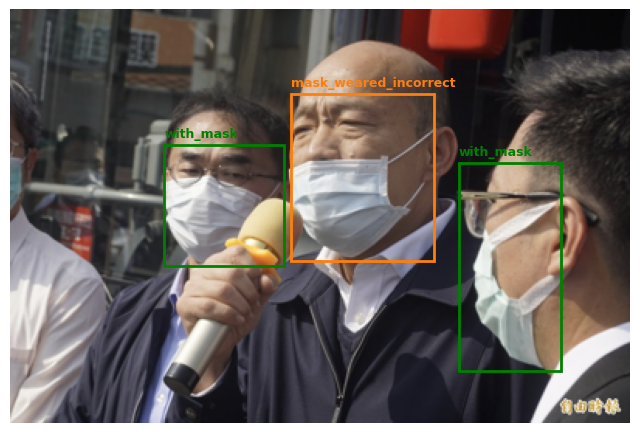

In [5]:
# Class colors and index mapping
classes_color = {'with_mask': 'g', 'without_mask': 'r', 'mask_weared_incorrect': 'tab:orange'}
classes_index = {'with_mask': 1, 'without_mask': 2, 'mask_weared_incorrect': 3}  # 0 = background

def show_bboxes(image, objects):
    """Display an image with colored bounding boxes."""
    fig, ax = plt.subplots(1, figsize=(8, 6))
    ax.imshow(image)
    for annotation in objects:
        xmin, ymin, xmax, ymax = annotation['bbox']
        color = classes_color.get(annotation['name'], 'b')
        rect = patches.Rectangle((xmin, ymin), (xmax - xmin), (ymax - ymin),
                                 linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, annotation['name'], color=color, fontsize=9, weight='bold')
    ax.axis('off')
    plt.show()

# Show a sample image
index = 99
objects = get_objects(os.path.join(ann_folder, f'maksssksksss{index}.xml'))
image = plt.imread(os.path.join(img_folder, f'maksssksksss{index}.png'))
show_bboxes(image, objects)

## 5. Custom PyTorch Dataset

In [6]:
class FaceMaskDataset(Dataset):
    def __init__(self, img_folder, annotation_folder, indexes, conversion=T.ToTensor()):
        self.conversion = conversion
        self.dataset = []
        for index in tqdm(indexes, desc='Loading data'):
            sample = {}
            sample['image'] = Image.open(os.path.join(img_folder, f'maksssksksss{index}.png')).convert('RGB')
            sample['objects'] = get_objects(os.path.join(annotation_folder, f'maksssksksss{index}.xml'))
            sample['id'] = index
            self.dataset.append(sample)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        target = {'boxes': [], 'labels': []}
        for obj in self.dataset[idx]['objects']:
            target['boxes'].append(obj['bbox'])
            target['labels'].append(classes_index[obj['name']])

        target['boxes'] = torch.as_tensor(target['boxes'], dtype=torch.float32)
        target['labels'] = torch.as_tensor(target['labels'], dtype=torch.int64)
        target['image_id'] = torch.tensor([self.dataset[idx]['id']])

        img = self.dataset[idx]['image']
        if self.conversion is not None:
            img = self.conversion(img)
        return img, target

## 6. Data Preparation

In [7]:
# Find valid image-annotation pairs
xmls = glob.glob(os.path.join(ann_folder, 'maksssksksss*.xml'))
indexes = sorted(
    int(re.search(r'maksssksksss(\d+)\.xml$', os.path.basename(x)).group(1))
    for x in xmls
)

valid_indexes = []
for i in indexes:
    png = os.path.join(img_folder, f'maksssksksss{i}.png')
    xml = os.path.join(ann_folder, f'maksssksksss{i}.xml')
    if os.path.exists(xml) and os.path.exists(png):
        valid_indexes.append(i)

print(f'Valid image-annotation pairs: {len(valid_indexes)}')

Valid image-annotation pairs: 853


In [8]:
# Train / Validation / Test split (70% / 15% / 15%)
random.seed(42)
shuffled = valid_indexes.copy()
random.shuffle(shuffled)

n = len(shuffled)
train_indexes = shuffled[:int(0.70 * n)]
val_indexes = shuffled[int(0.70 * n):int(0.85 * n)]
test_indexes = shuffled[int(0.85 * n):]

print(f'Train: {len(train_indexes)} | Val: {len(val_indexes)} | Test: {len(test_indexes)}')

Train: 597 | Val: 128 | Test: 128


## 7. Label Distribution Analysis

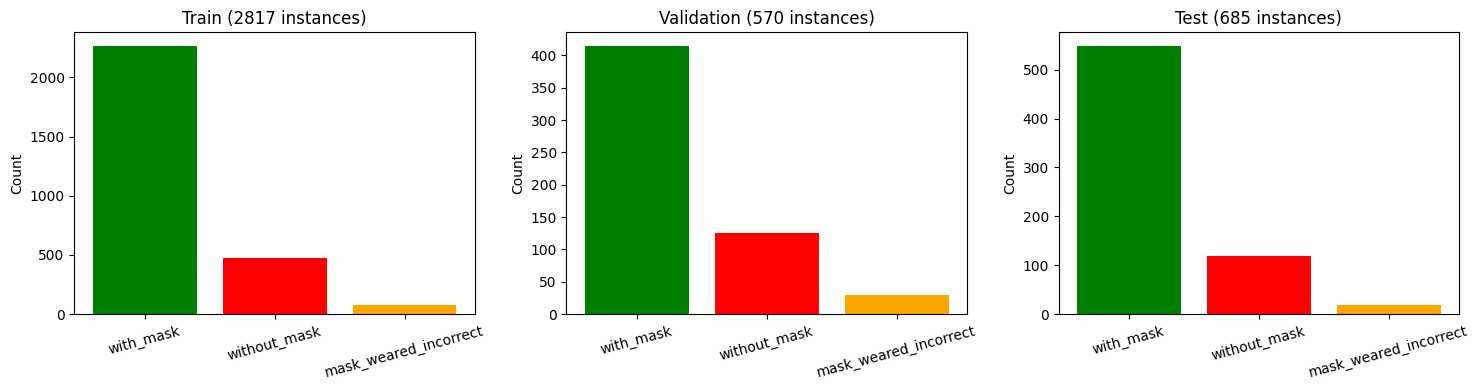

In [9]:
CLASSES = ['with_mask', 'without_mask', 'mask_weared_incorrect']

def count_labels(index_list, ann_dir):
    c = Counter()
    for i in index_list:
        xml_path = os.path.join(ann_dir, f'maksssksksss{i}.xml')
        try:
            objs = get_objects(xml_path)
        except FileNotFoundError:
            continue
        for o in objs:
            if o['name'] in CLASSES:
                c[o['name']] += 1
    return {k: c.get(k, 0) for k in CLASSES}

# Count per split
splits = {'Train': train_indexes, 'Validation': val_indexes, 'Test': test_indexes}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, idxs) in zip(axes, splits.items()):
    counts = count_labels(idxs, ann_folder)
    ax.bar(counts.keys(), counts.values(), color=['green', 'red', 'orange'])
    ax.set_title(f'{name} ({sum(counts.values())} instances)')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 8. Data Augmentation & DataLoaders

In [10]:
def get_transform(train):
    transforms = [T.ToTensor()]
    if train:
        transforms += [
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.RandomAutocontrast(p=0.2),
            T.RandomAdjustSharpness(sharpness_factor=1.5, p=0.2),
            T.RandomGrayscale(p=0.1),
            T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.2),
        ]
    return T.Compose(transforms)

def collate_fn(batch):
    return tuple(zip(*batch))

batch_size = 5

print('Loading training set...')
train_dataset = FaceMaskDataset(img_folder, ann_folder, train_indexes, conversion=get_transform(True))
print('Loading validation set...')
val_dataset = FaceMaskDataset(img_folder, ann_folder, val_indexes, conversion=get_transform(False))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn)

Loading training set...


Loading data:   0%|          | 0/597 [00:00<?, ?it/s]

Loading validation set...


Loading data:   0%|          | 0/128 [00:00<?, ?it/s]

## 9. Model — Faster R-CNN (ResNet50-FPN)

In [11]:
# Load Faster R-CNN pre-trained on COCO and replace the classification head
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
num_classes = 4  # 3 mask classes + background
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cuda


## 10. Training


--- Epoch 1/15 ---


Training:   0%|          | 0/120 [00:00<?, ?it/s]

Validation:   0%|          | 0/26 [00:00<?, ?it/s]

Train loss: 0.6797 | Val loss: 0.5357

--- Epoch 2/15 ---


Training:   0%|          | 0/120 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/26 [00:00<?, ?it/s]

Train loss: 0.2261 | Val loss: 0.3104

--- Epoch 15/15 ---


Training:   0%|          | 0/120 [00:00<?, ?it/s]

Validation:   0%|          | 0/26 [00:00<?, ?it/s]

Train loss: 0.2198 | Val loss: 0.3118


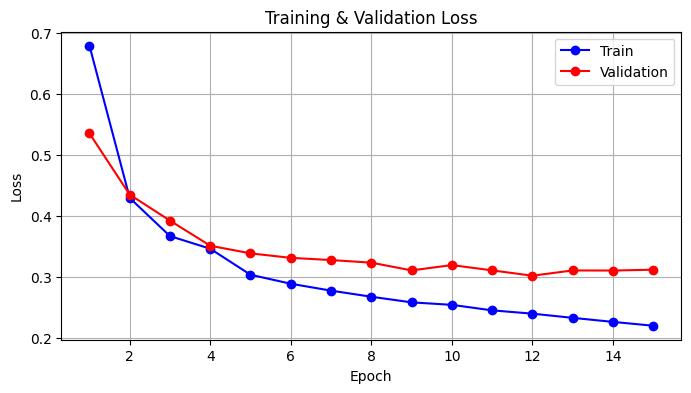

In [12]:
number_epochs = 15
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0005, momentum=0.9, weight_decay=1e-4)

train_loss = []
val_loss = []

for epoch in range(number_epochs):
    print(f'\n--- Epoch {epoch + 1}/{number_epochs} ---')

    # Training
    model.train()
    epoch_train_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training'):
        images = [img.to(device) for img in images]
        labels = [{k: v.to(device) for k, v in t.items()} for t in labels]

        loss_dict = model(images, labels)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_train_loss += losses.item()

    train_loss.append(epoch_train_loss / len(train_loader))

    # Validation
    model.train()  # keep in train mode to compute losses
    epoch_val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation', leave=False):
            images = [img.to(device) for img in images]
            labels = [{k: v.to(device) for k, v in t.items()} for t in labels]
            loss_dict = model(images, labels)
            epoch_val_loss += sum(loss_dict.values()).item()

    val_loss.append(epoch_val_loss / len(val_loader))
    print(f'Train loss: {train_loss[-1]:.4f} | Val loss: {val_loss[-1]:.4f}')

# Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(range(1, number_epochs + 1), train_loss, 'b-o', label='Train')
plt.plot(range(1, number_epochs + 1), val_loss, 'r-o', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## 11. Evaluation on Test Set

In [13]:
# Load test set
print('Loading test set...')
test_dataset = FaceMaskDataset(img_folder, ann_folder, test_indexes, conversion=get_transform(False))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn)

Loading test set...


Loading data:   0%|          | 0/128 [00:00<?, ?it/s]

In [14]:
# Test loss
@torch.no_grad()
def compute_loss_on_loader(model, loader, device):
    model.train()
    running, n_batches = 0.0, 0
    for images, targets in loader:
        images = [im.to(device) for im in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        running += sum(loss_dict.values()).item()
        n_batches += 1
    return running / max(1, n_batches)

test_loss = compute_loss_on_loader(model, test_loader, device)
print(f'Test loss: {test_loss:.4f}')

Test loss: 0.2630


In [15]:
# Precision, Recall, F1-Score per class (IoU >= 0.5)
label_names = {1: 'with_mask', 2: 'without_mask', 3: 'mask_weared_incorrect'}

@torch.no_grad()
def evaluate_fscore(model, loader, device, iou_thr=0.5, score_thr=0.5):
    model.eval()
    TP = defaultdict(int)
    FP = defaultdict(int)
    FN = defaultdict(int)

    for images, targets in loader:
        images = [im.to(device) for im in images]
        preds = model(images)

        for pred, tgt in zip(preds, targets):
            p_boxes = pred['boxes'].detach().cpu()
            p_labels = pred['labels'].detach().cpu()
            p_scores = pred['scores'].detach().cpu()
            keep = p_scores >= score_thr
            p_boxes, p_labels = p_boxes[keep], p_labels[keep]

            g_boxes = tgt['boxes'].detach().cpu()
            g_labels = tgt['labels'].detach().cpu()

            if len(p_boxes) == 0 and len(g_boxes) == 0:
                continue

            ious = box_iou(p_boxes, g_boxes) if (len(p_boxes) > 0 and len(g_boxes) > 0) else torch.zeros((len(p_boxes), len(g_boxes)))
            matched_g = set()

            for pi in range(len(p_boxes)):
                if len(g_boxes) == 0:
                    FP[int(p_labels[pi])] += 1
                    continue
                gi = torch.argmax(ious[pi]).item()
                if ious[pi, gi] >= iou_thr and gi not in matched_g and p_labels[pi] == g_labels[gi]:
                    TP[int(p_labels[pi])] += 1
                    matched_g.add(gi)
                else:
                    FP[int(p_labels[pi])] += 1

            for gi in range(len(g_boxes)):
                if gi not in matched_g:
                    FN[int(g_labels[gi])] += 1

    print(f'{"Class":25s} {"Precision":>10s} {"Recall":>10s} {"F1":>10s}   TP    FP    FN')
    print('-' * 85)
    macroP = macroR = macroF1 = 0.0
    for c in [1, 2, 3]:
        tp, fp, fn = TP[c], FP[c], FN[c]
        P = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        R = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0.0
        print(f'{label_names[c]:25s} {P:10.3f} {R:10.3f} {F1:10.3f}   {tp:4d}  {fp:4d}  {fn:4d}')
        macroP += P; macroR += R; macroF1 += F1
    print('-' * 85)
    print(f'{"Macro-average":25s} {macroP/3:10.3f} {macroR/3:10.3f} {macroF1/3:10.3f}')
    print(f'\n(IoU >= {iou_thr}, confidence >= {score_thr})')

evaluate_fscore(model, test_loader, device)

Class                      Precision     Recall         F1   TP    FP    FN
-------------------------------------------------------------------------------------
with_mask                      0.824      0.876      0.849    481   103    68
without_mask                   0.759      0.856      0.805    101    32    17
mask_weared_incorrect          0.000      0.000      0.000      0     0    18
-------------------------------------------------------------------------------------
Macro-average                  0.528      0.577      0.551

(IoU >= 0.5, confidence >= 0.5)


## 12. Visual Predictions on Test Images

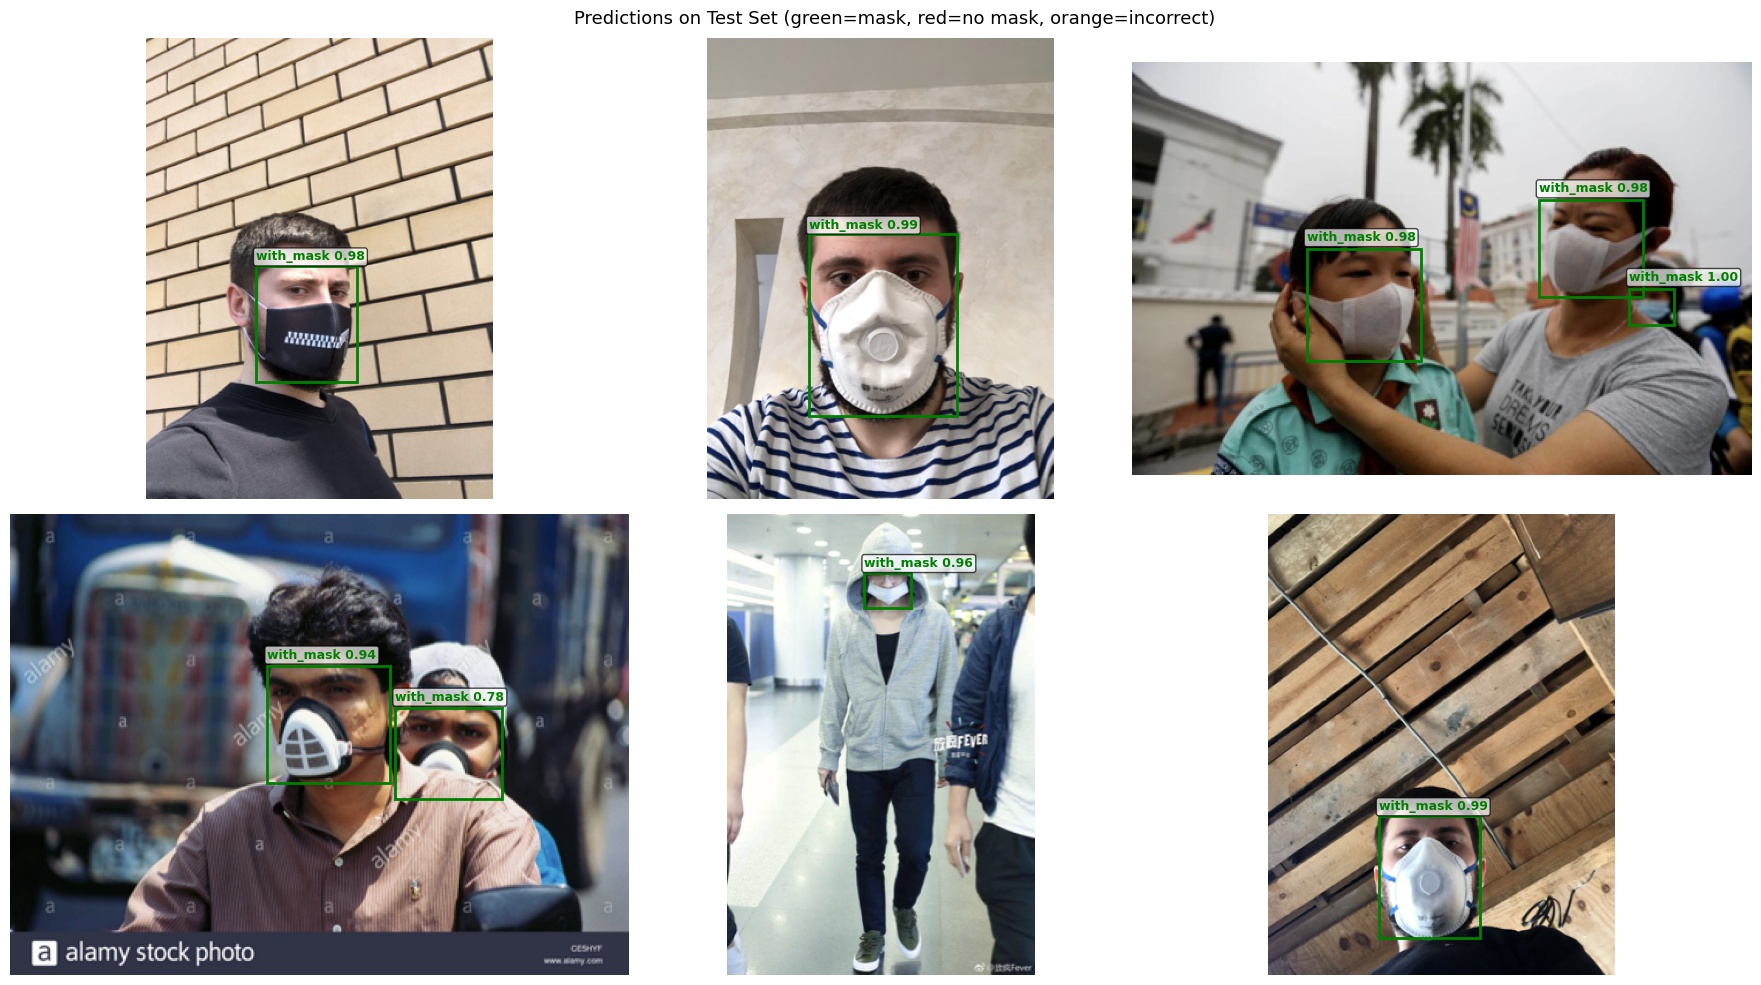

In [16]:
@torch.no_grad()
def show_predictions(model, dataset, device, num_images=6, score_thr=0.5):
    """Display model predictions with bounding boxes on test images."""
    model.eval()
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, ax in enumerate(axes.flat):
        if i >= len(dataset) or i >= num_images:
            ax.axis('off')
            continue

        img_tensor, target = dataset[i]
        pred = model([img_tensor.to(device)])[0]

        # Convert image for display
        img_np = img_tensor.permute(1, 2, 0).numpy()
        ax.imshow(img_np)

        # Draw predictions
        for box, label, score in zip(pred['boxes'].cpu(), pred['labels'].cpu(), pred['scores'].cpu()):
            if score < score_thr:
                continue
            x1, y1, x2, y2 = box.numpy()
            name = label_names.get(int(label), '?')
            color = classes_color.get(name, 'b')
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                     linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, f'{name} {score:.2f}', color=color, fontsize=9, weight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
        ax.axis('off')

    plt.suptitle('Predictions on Test Set (green=mask, red=no mask, orange=incorrect)', fontsize=13)
    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, device)